In [1]:
from pycromanager import Core
from pycromanager import Magellan
from pycromanager import Dataset
from pycromanager import Studio
# import thorlabs_apt as apt
# from thorlabs_apt import _APTAPI
import napari
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image
from scipy.signal import convolve2d
import pandas as pd

import FIM_functions

## Set up experiment object

In [2]:
exp = FIM_functions.Exp()

In [37]:
# exp.trigger_ms()
# exp.toggle_shutter()
# dir(exp.core)

# Image-guided MSI acquisition

## Basic image acq. (single snap)

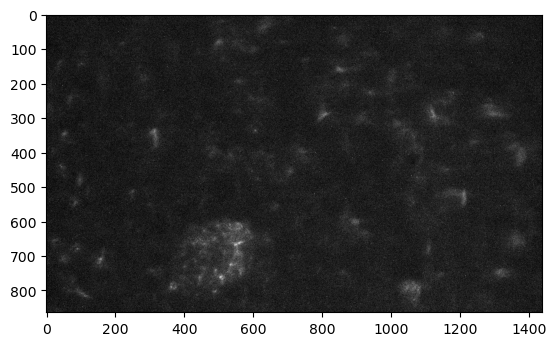

In [3]:
exp.core.set_property("TSICam","Gain", 48)
exp.core.set_exposure(300)

exp.core.snap_image()
tagged_image = exp.core.get_tagged_image()
pixels = np.reshape(tagged_image.pix,
                        newshape=[tagged_image.tags['Height'], tagged_image.tags['Width'],1])
# plot it
plt.imshow(pixels, cmap='gray')
plt.show()

## Magellen-based ROI exploration

In [ ]:
from pycromanager import ExploreAcquisition

acq = ExploreAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test1_301025', z_step_um=0, tile_overlap=0)
# acq.mark_finished()
# acq.await_completion()

In [47]:
studio = Studio()
pm = studio.positions()
posList = pm.get_position_list()
x_list=[]
y_list = []
for i in range(posList.get_number_of_positions()):
    pos=posList.get_position(i)
    x_list.append([pos.get(0).x])
    y_list.append([pos.get(0).y])
print(np.min(x_list))
print(np.max(x_list))
print(np.min(y_list))
print(np.max(y_list))

48810.904
49474.456
68663.272
69013.48000000001


### Calculate start position & XY parameters for exp file

In [48]:
[start_pos,image_width,image_height] = exp.calculate_ROI(xlist = x_list,ylist = y_list)

the ROI starting position will be [48841.24 68813.48] & the size will be 
0.44 mm by
0.85mm


### Return to starting position & generate exp file to start run

In [50]:
exp.core.set_xy_position(start_pos[0],start_pos[1])

x_pixel = 5
y_pixel = 5
filename = exp.prepare('cells4',x_pixel,y_pixel, image_width, image_height, x_pixel*10)


pixel size (5,5)um^2,
image size ~(0.44,0.85)mm^2
velocity 50um/s
This means a time per line of ~8.8s (plus flyback), and 170 or 171 lines.

New .exp file created for use in MassLynx (testing still required!):
C:/Users/olive/Dropbox/FIM/Scripts/2025_12_05_cells4.exp


In [12]:
# exp.send_file(filename[0], '146.179.86.142', 5001)

## Start Run!

In [51]:
exp.do_full_raster()

Start time: 2025-12-05 18:35:01.068881
0/171 done (0%)flyback
1/171 done (0%)flyback
2/171 done (1%)flyback
3/171 done (1%)flyback
4/171 done (2%)flyback
5/171 done (2%)flyback
6/171 done (3%)flyback
7/171 done (4%)flyback
8/171 done (4%)flyback
9/171 done (5%)flyback
10/171 done (5%)flyback
11/171 done (6%)flyback
12/171 done (7%)flyback
13/171 done (7%)flyback
14/171 done (8%)flyback
15/171 done (8%)flyback
16/171 done (9%)flyback
17/171 done (9%)flyback
18/171 done (10%)flyback
19/171 done (11%)flyback
20/171 done (11%)flyback
21/171 done (12%)flyback
22/171 done (12%)flyback
23/171 done (13%)flyback
24/171 done (14%)flyback
25/171 done (14%)flyback
26/171 done (15%)flyback
27/171 done (15%)flyback
28/171 done (16%)flyback
29/171 done (16%)flyback
30/171 done (17%)flyback
31/171 done (18%)flyback
32/171 done (18%)flyback
33/171 done (19%)flyback
34/171 done (19%)flyback
35/171 done (20%)flyback
36/171 done (21%)flyback
37/171 done (21%)flyback
38/171 done (22%)flyback
39/171 done (2

## Load/Unload

In [46]:

## load
exp.core.set_xy_position(50303,66321)

## unload
# exp.core.set_xy_position(52250,110250)

current_x = exp.core.get_x_position()
current_y = exp.core.get_y_position()
print(current_x)
print(current_y)

50303
62926


# Wellplate Reading

In [15]:
exp.wellplate_read(x_flip = -1)

Scanning well 1 ...
Next well.
Scanning well 2 ...
Next well.
Scanning well 3 ...
Next well.
Scanning well 4 ...
Next well.
Scanning well 5 ...
Next well.
Scanning well 6 ...
Next well.
Scanning well 7 ...
Next well.
Scanning well 8 ...
Next well.
Scanning well 9 ...
Next well.
Scanning well 10 ...
Next well.
Scanning well 11 ...
Next well.
Scanning well 12 ...
Next well.
Scanning well 13 ...
Next well.
Scanning well 14 ...
Next well.
Scanning well 15 ...
Next well.
Scanning well 16 ...
Next well.
Scanning well 17 ...
Next well.
Scanning well 18 ...
Next well.
Scanning well 19 ...
Next well.
Scanning well 20 ...
Next well.
Scanning well 21 ...
Next well.
Scanning well 22 ...
Next well.
Scanning well 23 ...
Next well.
Scanning well 24 ...
Next well.
Scanning well 25 ...
Next well.
Scanning well 26 ...
Next well.
Scanning well 27 ...
Next well.
Scanning well 28 ...
Next well.
Scanning well 29 ...
Next well.
Scanning well 30 ...
Next well.
Scanning well 31 ...
Next well.
Scanning well 32 

KeyboardInterrupt: 

In [ ]:
# from pycromanager import XYTiledAcquisition

# with XYTiledAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test_06102025', tile_overlap=10) as acq:
#     # 10 pixel overlap between adjacent tiles

#     # Acquire a 2 x 1 grid
#     acq.acquire({'axes': {'row': 0, 'col': 0}})
#     acq.acquire({'axes': {'row': 1, 'col': 0}})

In [72]:
# from pycromanager import ExploreAcquisition

# acq = ExploreAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test2_021224', z_step_um=0, tile_overlap=50)
# acq.mark_finished()
# acq.await_completion()

In [73]:
# TLX = core.get_x_position()
# TLY = core.get_y_position()
# print([TLX,TLY])
# print(dir(core))

In [5]:
# from pycromanager import MagellanAcquisition

# # no need to use the normal "with" syntax because these acquisition are cleaned up automatically
# acq = MagellanAcquisition(magellan_acq_index=0)

# # Or do this to launch an explore acquisition
# acq = MagellanAcquisition(magellan_explore=True)

# # Optional: block here until the acquisition is finished
# acq.await_completion()

In [ ]:
# from pycromanager import XYTiledAcquisition

# with XYTiledAcquisition(directory='C:/Users/olive/Dropbox/FIM/Data', name='test', tile_overlap=10) as acq:
#     # 10 pixel overlap between adjacent tiles

#     # Acquire a 2 x 1 grid
#     acq.acquire({'axes': {'row': 0, 'col': 0}})
#     acq.acquire({'axes': {'row': 1, 'col': 0}})